<a href="https://colab.research.google.com/github/vaishakhmohan77/Python-Assignments./blob/main/Assignment_11_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1) Loading the Taxis Dataset

import seaborn as sns
import pandas as pd
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [2]:
# 2) Handling Missing Values

# a) Check for missing values in the dataset and identify columns with missing data.

print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [3]:
# Impute missing values using appropriate strategies based on the column type (e.g.,using mean, median, or mode for numerical columns, and mode for categorical columns).

df['payment'] = df['payment'].fillna(df['payment'].mode()[0])
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [4]:
# ➢ For columns that are critical and cannot be reasonably imputed, remove rows with missing values to maintain data integrity.

df = df.dropna(subset=['pickup', 'dropoff', 'distance', 'fare'])
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


datetime64[ns]


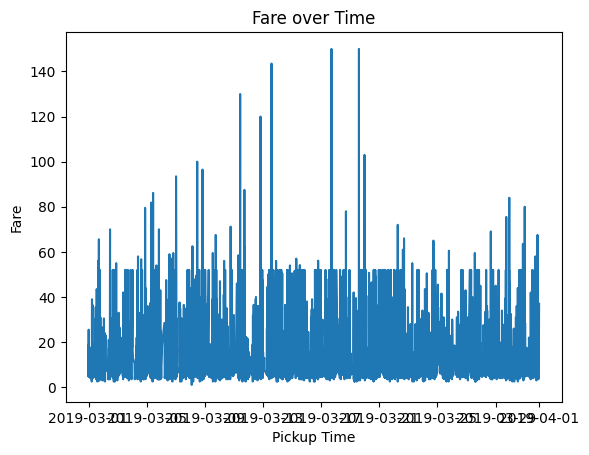

In [8]:
# 3) Visualizations using Matplotlib/Pandas Plot:
# Line Chart

df['pickup'] = pd.to_datetime(df['pickup'])
print(df['pickup'].dtype)

import matplotlib.pyplot as plt

df_sorted = df.sort_values('pickup')

plt.plot(df_sorted['pickup'], df_sorted['fare'])
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare over Time')
plt.show()

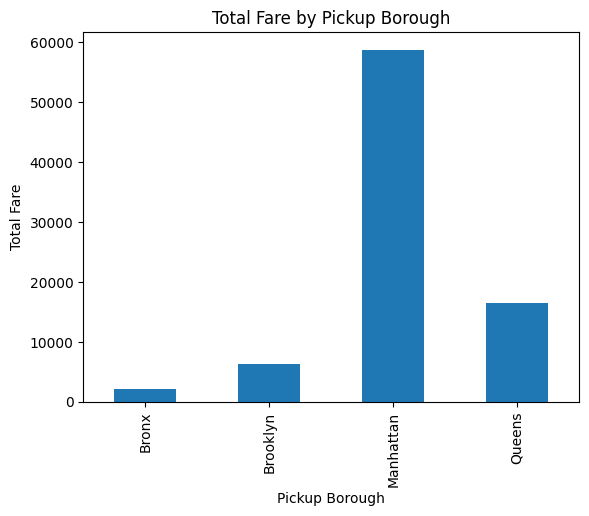

In [9]:
# Bar Chart

borough_fare = df.groupby('pickup_borough')['fare'].sum()

borough_fare.plot(kind='bar')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.show()

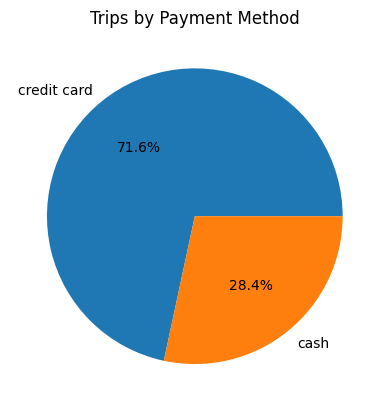

In [10]:
# Pie Chart

payment_counts = df['payment'].value_counts()

payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Trips by Payment Method')
plt.show()

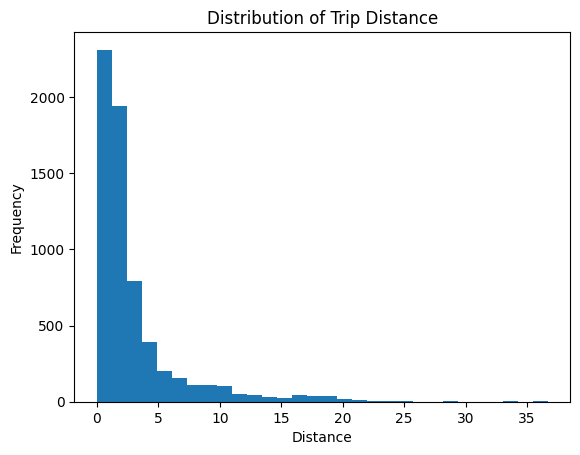

In [11]:
# Histogram

plt.hist(df['distance'], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Distance')
plt.show()

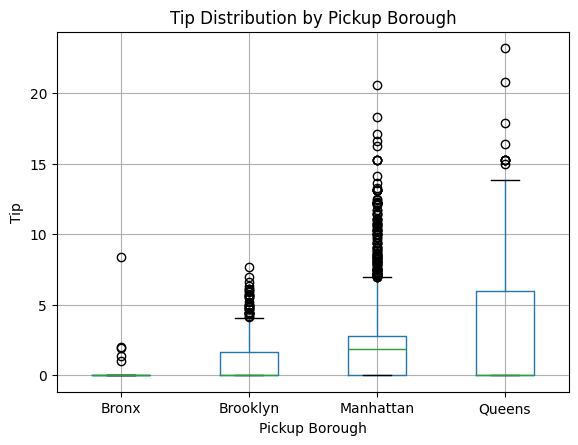

In [12]:
# Box Plot

df.boxplot(column='tip', by='pickup_borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip')
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')
plt.show()

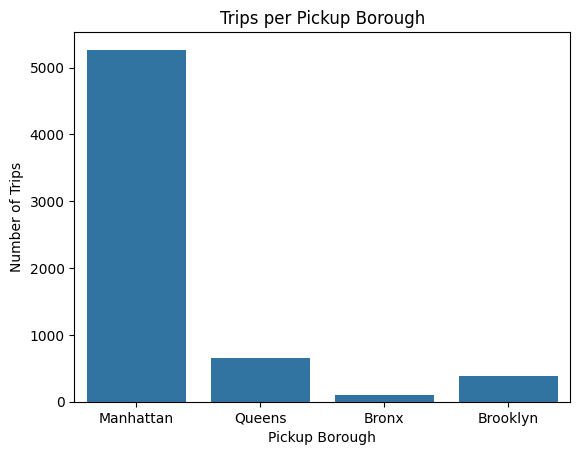

In [13]:
# Visualizations using Seaborn:
# Count Plot

sns.countplot(data=df, x='pickup_borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Trips per Pickup Borough')
plt.show()

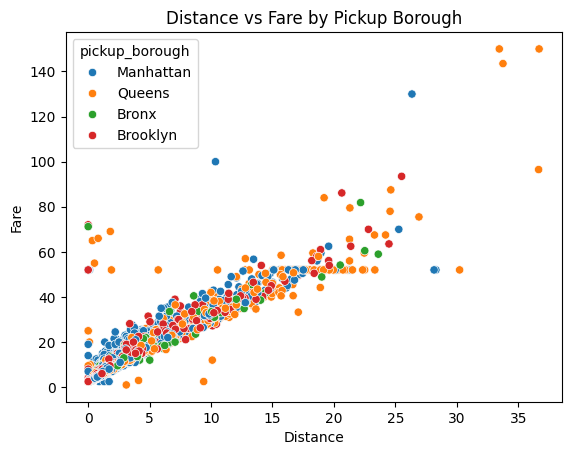

In [14]:
# Scatter Plot

sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Distance vs Fare by Pickup Borough')
plt.show()

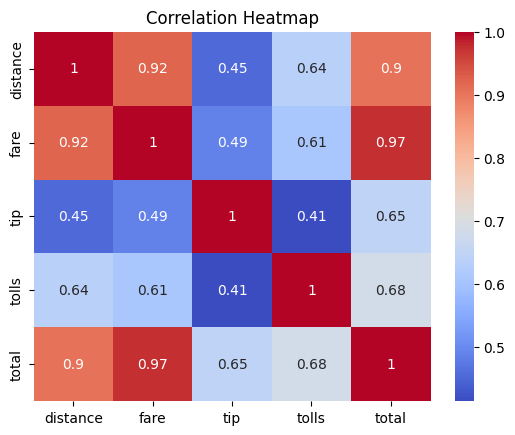

In [15]:
# Heatmap

correlation_matrix = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

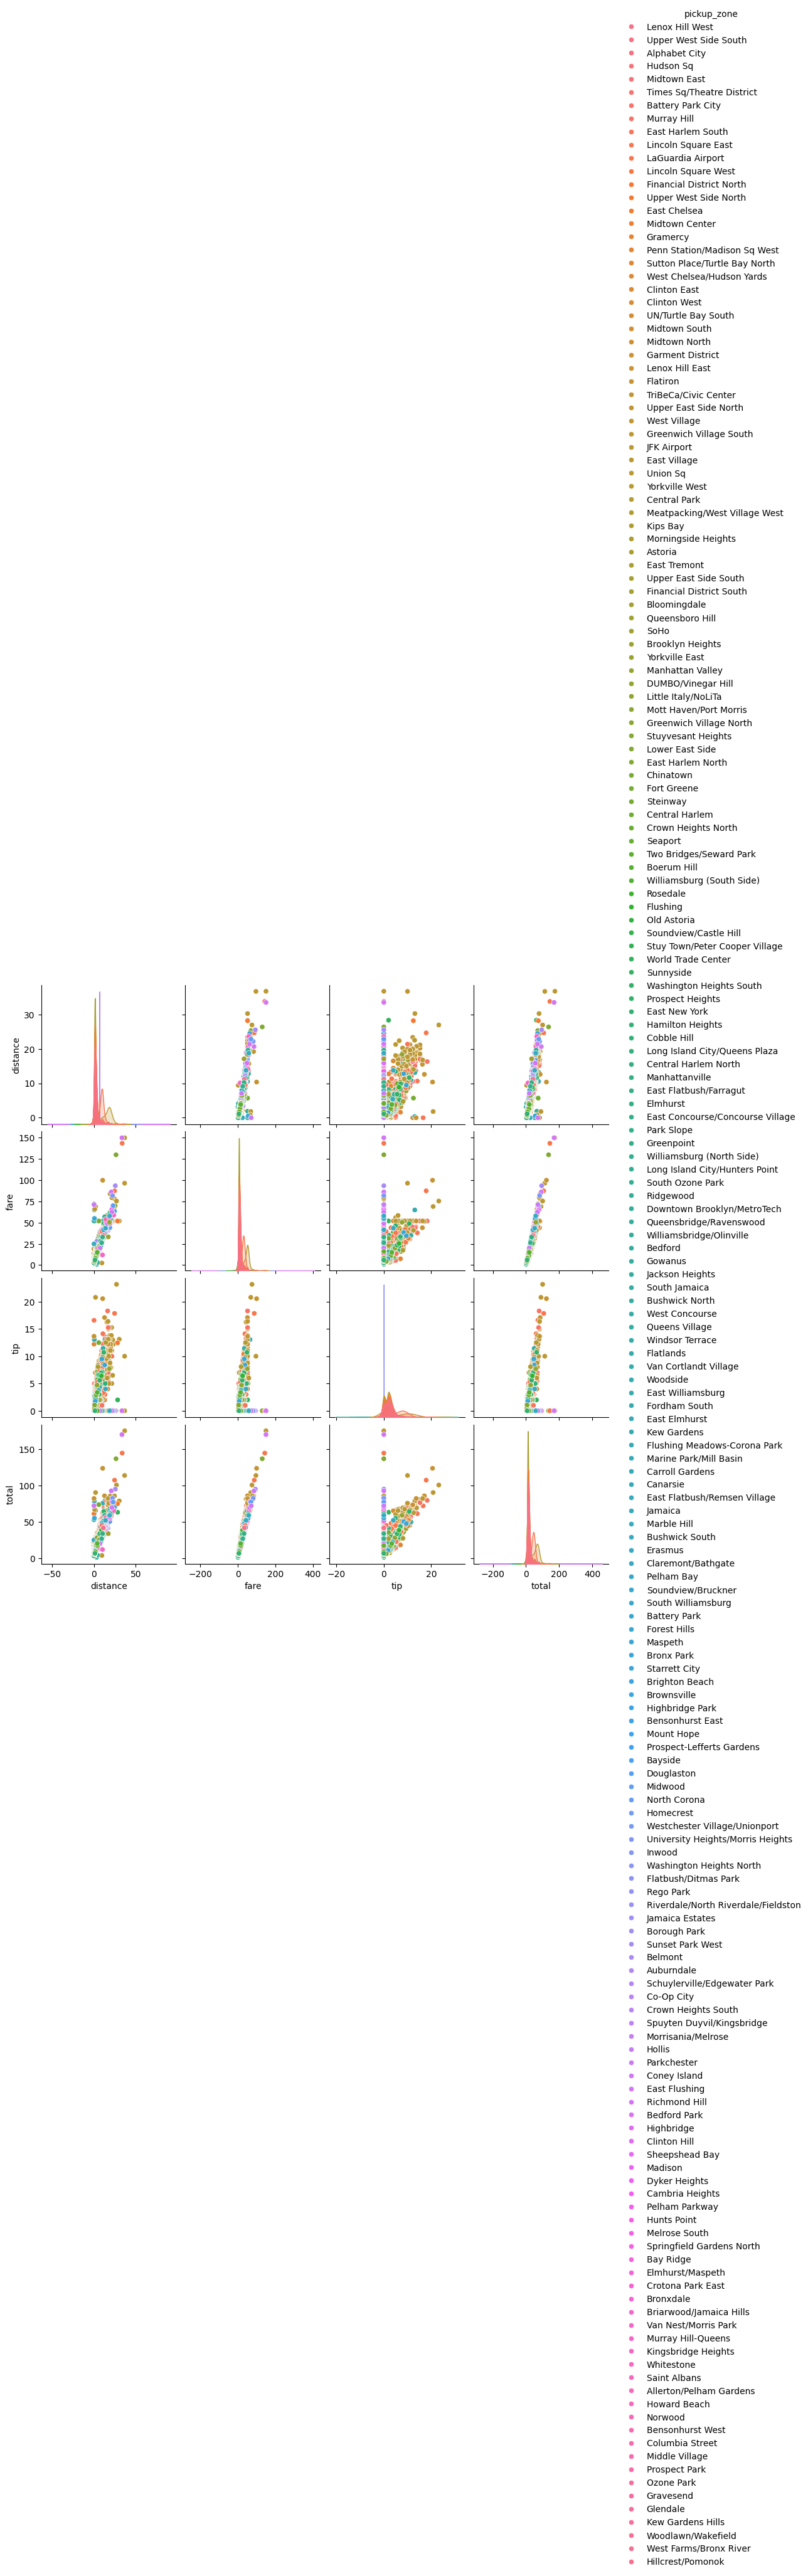

In [16]:
# Pair Plot

sns.pairplot(df, vars=['distance', 'fare', 'tip', 'total'], hue='pickup_zone')
plt.show()

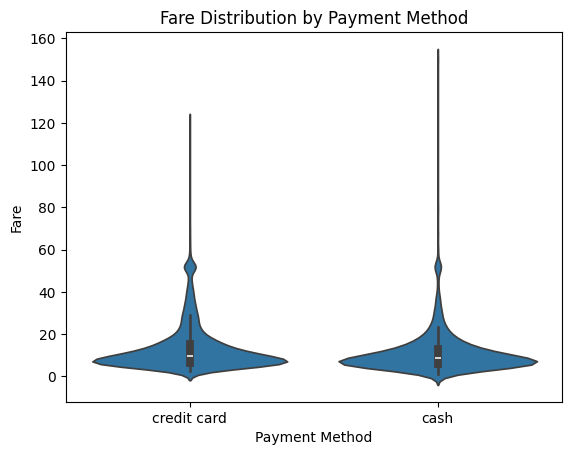

In [17]:
# Violin Plot

sns.violinplot(data=df, x='payment', y='fare')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')
plt.show()